In [1]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow.compat.v1 as tf1
tf.compat.v1.disable_v2_behavior() # 1.x 兼容模式
# TF 2.16+ disable_v2_behavior 不再导出 Session 等到顶层, 手动补上
tf.Session = tf1.Session
tf.placeholder = tf1.placeholder
tf.global_variables_initializer = tf1.global_variables_initializer
tf.Variable = tf1.Variable
tf.train = tf1.train
tf.layers = tf1.layers
tf.losses = tf1.losses


Instructions for updating:
non-resource variables are not supported in the long term


## 构造数据

In [2]:
# 调用接口下载数据
mnist = tf.keras.datasets.mnist
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()
print(train_images.shape)
print(train_labels.shape)
print(test_images.shape)
print(test_labels.shape)


(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


In [3]:
# 显示数据和标签
def plot_img(img, label):
    plt.imshow(img, cmap=plt.cm.binary)
    plt.title("True Label: %d" % label)
    plt.show()

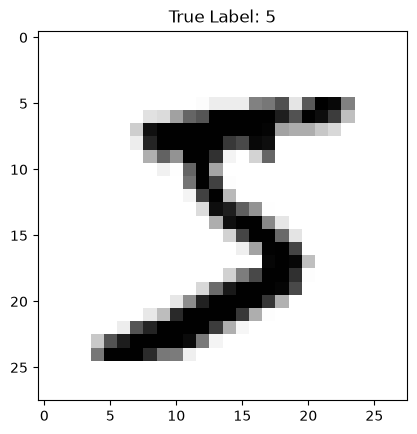

In [4]:
plot_img(train_images[0], train_labels[0])

In [5]:
data_0 = []
data_1 = []
for img,label in zip(train_images,train_labels):
    if label == 0:
        img = img.reshape(28*28)/255
        img = np.append(img,label)
        data_0.append(img)
    if label == 1:
        img = img.reshape(28*28)/255
        img = np.append(img,label)
        data_1.append(img)


In [6]:
all_data = np.concatenate([data_0,data_1])
print(all_data.shape)


(12665, 785)


In [7]:
np.random.shuffle(all_data)

In [8]:
train_data = all_data[:-200]
test_data = all_data[-200:]

## 数据分块

In [15]:
def gen_batch(data,batch_size):
    np.random.shuffle(data)
    for i in range(0,len(data),batch_size):
        yield data[i:i+batch_size][:,0:784],data[i:i+batch_size][:,784].reshape(-1,1)
    remainder = len(data) % batch_size
    if remainder > 0:
        yield data[-remainder:][:,0:784],data[-remainder:][:,784].reshape(-1,1)


In [14]:
for x_,y_ in gen_batch(train_data,128):
    print(x_.shape,y_.shape)
    break

(128, 784) (128, 1)


## 超参数

In [11]:
learning_rate = 0.01
num_train_epochs = 50
display_step = 100
batch_size = 128


In [12]:
graph = tf.Graph()
with graph.as_default():
    x = tf.placeholder(shape=[None,784], dtype=tf.float32, name='x')
    y = tf.placeholder(shape=[None,1], dtype=tf.float32, name='y')

    w = tf.Variable(tf.ones(shape=[784,1], dtype=tf.float32), name='w')
    b = tf.Variable(0, dtype=tf.float32, name='b')
    logits = tf.matmul(x, w) + b
    y_pred = tf.sigmoid(logits)
    # 定义损失函数
    with tf.name_scope('loss'):
        loss = tf.reduce_mean(tf.nn.sigmoid_cross_entropy_with_logits(logits=logits, labels=y), name='loss')
    # 定义优化器
    with tf.name_scope('SGD'):
        
        optimizer = tf.train.GradientDescentOptimizer(learning_rate=learning_rate)
        train_step = optimizer.minimize(loss)
    # 定义正确率标签
    with tf.name_scope('accuracy'):
        correct_pred = tf.cast(tf.greater_equal(y_pred, 0.5), tf.float32)
        accuracy = tf.reduce_mean(tf.cast(tf.equal(correct_pred,y), tf.float32))


In [16]:
with tf.Session(graph=graph) as sess:
    sess.run(tf.global_variables_initializer())
    step = 0
    for epoch in range(num_train_epochs):
        for x_,y_ in gen_batch(train_data, batch_size):
            step += 1
            _, loss_val, accuracy_val = sess.run([train_step, loss, accuracy], feed_dict={x:x_, y:y_})
            if step % display_step == 0:
                w_val = sess.run(w)
                b_val = sess.run(b)
                print(f'Epoch {epoch}, Step {step}, W: {w_val[0,0]:.4f}, Loss: {loss_val:.4f}, Accuracy: {accuracy_val:.4f}')
    # 评估模型
    print('training over')
    x_test,y_test = next(gen_batch(test_data, 200))
    loss_test, accuracy_test = sess.run([loss, accuracy], feed_dict={x:x_test, y:y_test})
    print(f'Test Loss: {loss_test:.4f}, Accuracy: {accuracy_test:.4f}')
    res_weight = sess.run([w,b])
    print(f'Weight: {res_weight}')


Epoch 1, Step 100, W: 1.0000, Loss: 51.0010, Accuracy: 0.5234
Epoch 2, Step 200, W: 1.0000, Loss: 33.2678, Accuracy: 0.5312
Epoch 3, Step 300, W: 1.0000, Loss: 22.5986, Accuracy: 0.4531
Epoch 4, Step 400, W: 1.0000, Loss: 4.5001, Accuracy: 0.6797
Epoch 5, Step 500, W: 1.0000, Loss: 0.5226, Accuracy: 0.9219
Epoch 6, Step 600, W: 1.0000, Loss: 0.8149, Accuracy: 0.9062
Epoch 7, Step 700, W: 1.0000, Loss: 0.0752, Accuracy: 0.9766
Epoch 8, Step 800, W: 1.0000, Loss: 0.1286, Accuracy: 0.9609
Epoch 9, Step 900, W: 1.0000, Loss: 0.1470, Accuracy: 0.9688
Epoch 10, Step 1000, W: 1.0000, Loss: 0.4109, Accuracy: 0.9688
Epoch 11, Step 1100, W: 1.0000, Loss: 0.3487, Accuracy: 0.9375
Epoch 12, Step 1200, W: 1.0000, Loss: 0.0594, Accuracy: 0.9844
Epoch 13, Step 1300, W: 1.0000, Loss: 0.0662, Accuracy: 0.9766
Epoch 14, Step 1400, W: 1.0000, Loss: 0.0564, Accuracy: 0.9844
Epoch 15, Step 1500, W: 1.0000, Loss: 0.0366, Accuracy: 0.9922
Epoch 16, Step 1600, W: 1.0000, Loss: 0.0106, Accuracy: 0.9922
Epoch 1

## 模型预测

In [21]:
def plot_img(img, label):
    plt.imshow(img.reshape(28,28), cmap='binary')
    plt.title(f'Label: {label}')
    plt.show()

In [27]:
test_img = test_data[3,:784]

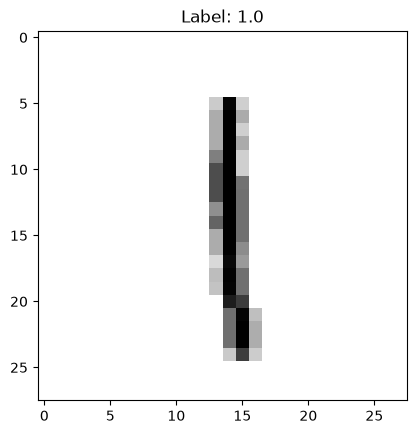

In [32]:
plot_img(test_img, test_data[3,784])

In [34]:
graph = tf.Graph()
with graph.as_default():
    x = tf.placeholder(shape=[None,784], dtype=tf.float32, name='x')
    y = tf.placeholder(shape=[None,1], dtype=tf.float32, name='y')

    w = tf.Variable(res_weight[0], dtype=tf.float32, name='w')
    b = tf.Variable(res_weight[1], dtype=tf.float32, name='b')
    logits = tf.matmul(x, w) + b
    y_pred = tf.sigmoid(logits)
    # 定义损失函数
    with tf.name_scope('loss'):
        loss = tf.reduce_mean(tf.nn.sigmoid_cross_entropy_with_logits(logits=logits, labels=y), name='loss')
    # 定义优化器
    with tf.name_scope('SGD'):
        
        optimizer = tf.train.GradientDescentOptimizer(learning_rate=learning_rate)
        train_step = optimizer.minimize(loss)
    # 定义正确率标签
    with tf.name_scope('accuracy'):
        correct_pred = tf.cast(tf.greater_equal(y_pred, 0.5), tf.float32)
        accuracy = tf.reduce_mean(tf.cast(tf.equal(correct_pred,y), tf.float32))


In [33]:
with tf.Session(graph=graph) as sess:
    sess.run(tf.global_variables_initializer())
    x_ = test_data[3,:784].reshape(1,-1)
    res_p = sess.run([correct_pred], feed_dict={x:x_})
    print(res_p)


[array([[1.]], dtype=float32)]
